In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid
from scipy.signal import unit_impulse
from scipy.interpolate import CubicSpline
from scipy.stats import norm, lognorm

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 3. RTD en reactores ideales

## 3.1 Reactores Batch y PFR

Las curvas RTD para reactores Batch y PFR son las mas simples a considerar.
Todos los átomos que salen de estos reactores ideales han pasado el mismo tiempo dentro del reactor.



En este caso la función $E(t)$ tiene la forma de una Función Delta de Dirac:

$$E(t) = \mathbf{\delta} \left(t - \tau\right)$$


La función acumulada $F(t)$ tiene la forma de una función escalón Heaviside:

$$F(t) = \int_{0}^{t} \mathbf{\delta} \left(t - \tau\right) dt$$



Las funciones normalizadas tendrán entonces la forma:

$$E(\Theta) = \mathbf{\delta} \left( \Theta - 1 \right)$$

$$F(\Theta) = \int_{0}^{\Theta} \mathbf{\delta} \left(\Theta - 1\right) d \Theta$$

$$\Theta = \frac{t}{\tau}$$

<details>
<summary><b>Propiedades de la Función Delta de Dirac</b></summary>

<div class="alert alert-info">

$$\mathrm{\delta}(x) \left\{
    \begin{matrix*}[l]
    0 & \forall & x\ne0 \\
    \infty & \forall & x=0 \\
    \end{matrix*}
\right.$$

$$\int_{-\infty}^{\infty} \mathbf{\delta}(x) dx = 1$$

$$\int_{-\infty}^{\infty} g(x) \mathbf{\delta}(x - \tau) dx = g(\tau)$$

</div>

</details>

In [ ]:
pfrE = lambda t, tau: unit_impulse(len(t), idx=np.argmin(abs(t-tau)))
pfrF = lambda t, tau: np.heaviside(t-tau, 0)

**Curvas RTD:**

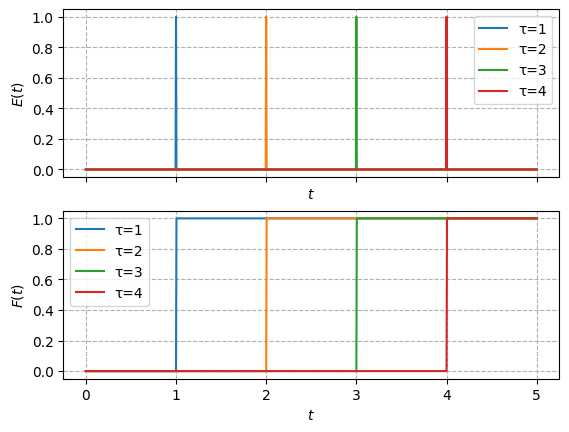

In [92]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    # E(t)
    ax0.plot(t, pfrE(t, tau), label=f'τ={tau}')
    # F(t)
    ax1.plot(t, pfrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(t)$")
ax1.set_ylabel(r"$F(t)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$t$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Curvas RTD normalizadas:**

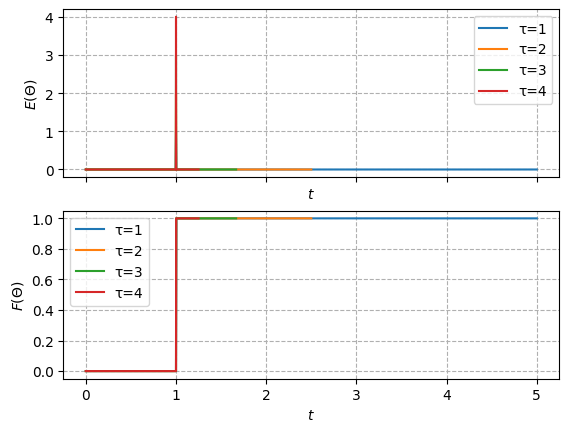

In [108]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    th = t/tau
    # E(Θ) = τ E(t)
    ax0.plot(th, tau*pfrE(t, tau), label=f'τ={tau}')
    # F(Θ)
    ax1.plot(th, pfrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(\Theta)$")
ax1.set_ylabel(r"$F(\Theta)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$\Theta$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Tiempo de residencia promedio:**

$$t_m =  \int_{0}^{\infty} t E(t) dt = \int_{0}^{\infty} t \mathbf{\delta} \left(t - \tau\right) dt = \tau$$

$$\tau = \frac{V}{\dot{Q}}$$

**Varianza:**

$$\sigma^2 = \int_{0}^{\infty} \left(t-\tau\right)^2 \mathbf{\delta} \left(t - \tau\right) dt = 0$$

## 3.2 CSTR

En un reactor CSTR ideal, la concentración de trazador en el efluente es igual a la concentración del trazador en todo el reactor.

<details>
<summary><b>Balance de trazador en un CSTR</b></summary>

<div class="alert alert-info">

El balance de materia para el trazador inerte, que se ha inyectado como un pulso en $t=0$, se escribe:

$$\underbrace{V \frac{dC}{dt}}_{\text{Acumulación}} = \underbrace{0}_{\text{Entradas}} - \underbrace{\dot{Q} C}_{\text{Salidas}}$$

Integrando la ecuación:

$$-\frac{1}{\tau} \int_{0}{t} dt = \int_{C_{0}}^{C} \frac{dC}{C}$$

$$C(t) = C_{0} \exp \left(- \frac{\displaystyle t}{\displaystyle \tau}\right)$$

Obteniendo $E(t)$:

$$E(t) = \frac{\displaystyle C(t)}{\displaystyle \int_{0}^{\infty} C(t) dt}$$

$$E(t) = \frac{\displaystyle C_{0} \exp \left(\frac{-\displaystyle t}{\displaystyle \tau}\right)}{\displaystyle \int_{0}^{\infty} C_{0} \exp \left(-\frac{\displaystyle t}{\displaystyle \tau}\right) dt} = \frac{\displaystyle \exp \left(-\frac{t}{\tau} \right)}{\tau}$$

</div>

</details>



En este caso la función $E(t)$ tiene un comportamiento de decaimiento exponencial:

$$E(t) = \frac{1}{\tau} \exp \left(- \frac{\displaystyle t}{\displaystyle \tau}\right)$$



La función acumulada $F(t)$ tiene forma de crecimiento exponencial:

$$F(t) =  \int_{0}^{t} \frac{1}{\tau} \exp \left( - \frac{\displaystyle t}{\displaystyle \tau}\right) dt$$

$$F(t)  = 1 - \exp \left( -\frac{\displaystyle t}{\displaystyle \tau}\right)$$



Las funciones normalizadas tendrán entonces la forma:

$$E(\Theta) = \exp \left( -\Theta \right)$$

$$F(\Theta) = 1 - \exp \left( - \Theta \right)$$

$$\Theta = \frac{t}{\tau}$$

In [61]:
cstrE = lambda t, tau: 1/tau * np.exp(-t/tau)
cstrF = lambda t, tau: 1 - np.exp(-t/tau)

**Curvas RTD:**

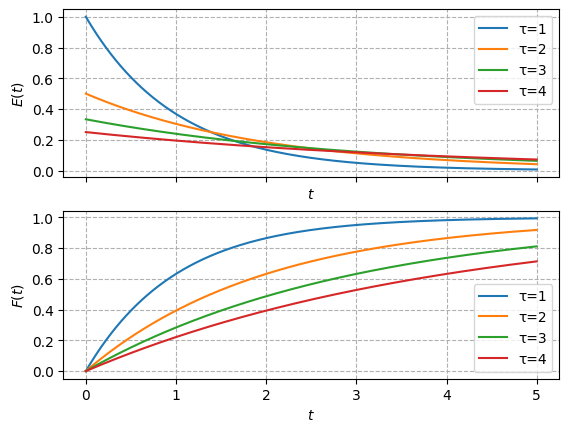

In [93]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    # E(t)
    ax0.plot(t, cstrE(t, tau), label=f'τ={tau}')
    # F(t)
    ax1.plot(t, cstrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(t)$")
ax1.set_ylabel(r"$F(t)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$t$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Curvas RTD normalizadas:**

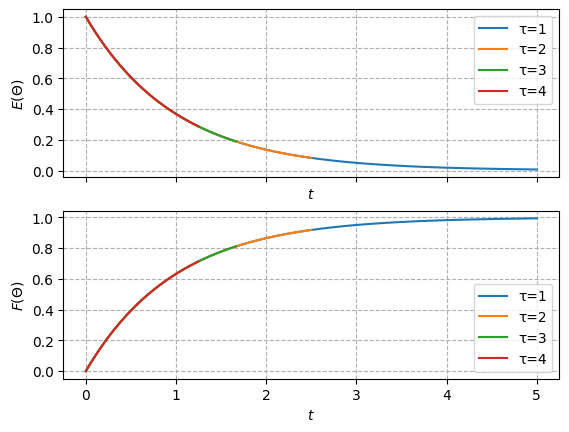

In [106]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    th = t/tau
    # E(Θ) = τ E(t)
    ax0.plot(th, tau*cstrE(t, tau), label=f'τ={tau}')
    # F(Θ)
    ax1.plot(th, cstrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(\Theta)$")
ax1.set_ylabel(r"$F(\Theta)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$\Theta$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Tiempo de residencia promedio:**

$$t_m =  \int_{0}^{\infty} t E(t) dt = \int_{0}^{\infty} \frac{t}{\tau} \exp \left( - \frac{\displaystyle t}{\displaystyle \tau} \right) dt = \tau$$

**Varianza:**

$$\sigma^2 = \int_{0}^{\infty} \frac{(t-\tau)^2}{\tau} \exp \left( - \frac{\displaystyle t}{\displaystyle \tau} \right) dt = \tau^2$$

## 3.3 Reactor con flujo laminar (LFR)

En un reactor tubular con flujo laminar tiene un perfil de velocidad parabólico. Como consecuencia de esto, las moleculas en el centro pasarán menor tiempo en el reactor que las moleculas cerca de las paredes.



En este caso la función $E(t)$ tiene un comportamiento de decaimiento exponencial:

$$E(t) = \left\{ \begin{matrix*}[l] 
0 & \forall & t< \frac{\displaystyle \tau}{2} \\
\frac{\displaystyle \tau^2}{\displaystyle 2 t^3} & \forall & t \ge \frac{\displaystyle \tau}{2} \\
\end{matrix*}\right.$$

La función acumulada $F(t)$ tiene forma de crecimiento exponencial:

$$F(t) = \left\{ \begin{matrix*}[l] 
0 & \forall & t< \frac{\displaystyle \tau}{2} \\
1 - \frac{\displaystyle \tau^2}{\displaystyle 4t^2} & \forall & t \ge \frac{\displaystyle \tau}{2} \\
\end{matrix*}\right.$$

Las funciones normalizadas tendrán entonces la forma:

$$E(\Theta) = \left\{ \begin{matrix*}[l] 
0 & \forall & \Theta < 0.5 \\
\frac{\displaystyle 1}{\displaystyle 2 \Theta^3} & \forall & \Theta \ge 0.5 \\
\end{matrix*}\right.$$

$$F(\Theta) = \left\{ \begin{matrix*}[l] 
0 & \forall & \Theta < 0.5 \\
1 - \frac{\displaystyle 1}{\displaystyle 4 \Theta^2} & \forall & \Theta \ge 0.5 \\
\end{matrix*}\right.$$

$$\Theta = \frac{t}{\tau}$$

In [ ]:
eps = 1e-10
lfrE = lambda t, tau: 0*(t<tau/2) + (tau**2)/(2*t**3+eps)*(t>=tau/2)
lfrF = lambda t, tau: 0*(t<tau/2) + (1 - (tau**2)/(4*t**2+eps))*(t>=tau/2)

**Curvas RTD:**

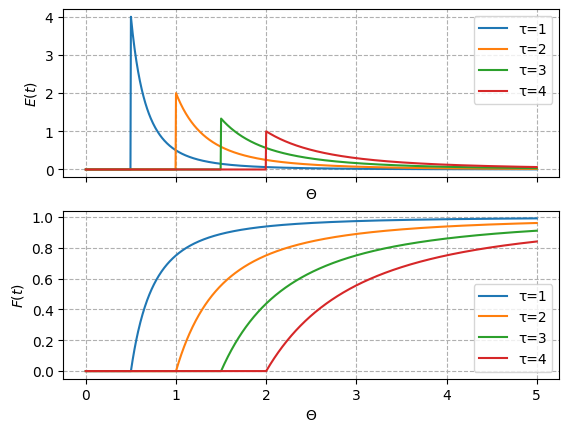

In [109]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    # E(t)
    ax0.plot(t, lfrE(t, tau), label=f'τ={tau}')
    # F(t)
    ax1.plot(t, lfrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(t)$")
ax1.set_ylabel(r"$F(t)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$t$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Curvas RTD normalizadas:**

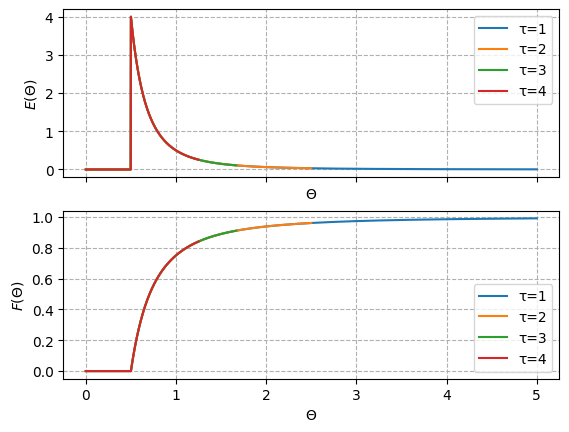

In [110]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
for tau in [1, 2, 3, 4]:
    th = t/tau
    # E(Θ) = τ E(t)
    ax0.plot(th, tau*lfrE(t, tau), label=f'τ={tau}')
    # F(Θ)
    ax1.plot(th, lfrF(t, tau), label=f'τ={tau}')
ax0.set_ylabel(r"$E(\Theta)$")
ax1.set_ylabel(r"$F(\Theta)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$\Theta$")
    ax.grid(ls='--')
    ax.legend()
plt.show()

**Tiempo de residencia promedio:**

$$t_m =  \int_{0}^{\infty} t E(t) dt = \frac{\tau^2}{2} \int_{\tau/2}^{\infty} \frac{dt}{t^2} = \tau$$

$$\tau = \frac{V}{\dot{Q}}$$

## 3.4 Comparación de curvas RTD normalizadas

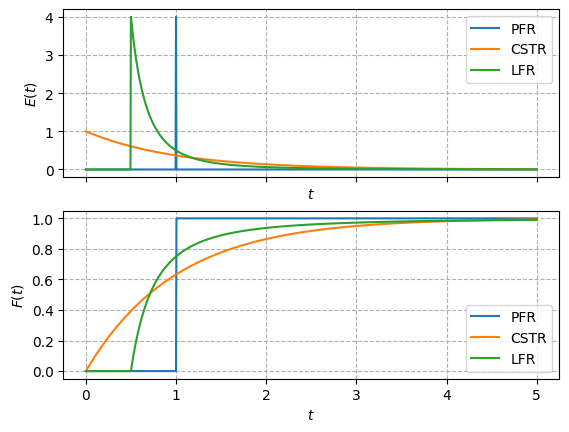

In [113]:
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
t = np.linspace(0, 5, 1001)
tau = 1
# E(t)
ax0.set_prop_cycle(None)
ax0.plot(t, 4*pfrE(t, tau), label='PFR')
ax0.plot(t, cstrE(t, tau), label='CSTR')
ax0.plot(t, lfrE(t, tau), label='LFR')
# F(t)
ax0.set_prop_cycle(None)
ax1.plot(t, pfrF(t, tau), label="PFR")
ax1.plot(t, cstrF(t, tau), label="CSTR")
ax1.plot(t, lfrF(t, tau), label='LFR')
ax0.set_ylabel(r"$E(t)$")
ax1.set_ylabel(r"$F(t)$")
for ax in (ax0, ax1):
    ax.set_xlabel(r"$t$")
    ax.grid(ls='--')
    ax.legend()
plt.show()